# Mutual Fund Capstone Project - Performance Analytics (Day 4)

This notebook contains quantitative performance metrics for all 40 mutual fund schemes. It queries the SQLite star schema database `bluestock_mf.db` to calculate CAGRs (1yr, 3yr, 5yr/Max), risk-adjusted returns (Sharpe, Sortino), market risk coefficients (Alpha, Beta), and worst drawdown ranges. It also constructs a composite Fund Scorecard (0-100), outputs result CSVs, and plots a 3-year benchmark comparison tracking top funds vs. Nifty 50 and Nifty 100 index benchmarks.

In [1]:
# Import dependencies
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Define plotting configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Create SQLite engine connection (handles notebooks folder path context)
db_rel_path = '../bluestock_mf.db' if os.path.exists('../bluestock_mf.db') else 'bluestock_mf.db'
conn = sqlite3.connect(db_rel_path)
print(f"Connected to SQLite database at: {os.path.abspath(db_rel_path)}")
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports/plots', exist_ok=True)
processed_dir = '../data/processed'
plots_dir = '../reports/plots'


Connected to SQLite database at: C:\Bluestock\bluestock_mf.db


In [2]:
# Load NIFTY100 daily returns as our index returns for Alpha/Beta regression
query = """
SELECT date, close_value
FROM fact_benchmark
WHERE index_name = 'NIFTY100'
ORDER BY date
"""
nifty100_df = pd.read_sql_query(query, conn)
nifty100_df['date'] = pd.to_datetime(nifty100_df['date'])
nifty100_df['nifty_return'] = nifty100_df['close_value'].pct_change()
nifty100_df = nifty100_df.dropna()
print(f"Loaded {len(nifty100_df)} NIFTY100 daily returns.")


Loaded 1149 NIFTY100 daily returns.


In [3]:
# Main calculations for all 40 funds
rf_annual = 0.065  # 6.5% risk-free rate proxy
rf_daily = rf_annual / 252

# Get list of all schemes
funds_df = pd.read_sql_query("""
SELECT amfi_code, scheme_name, fund_house, category, plan, expense_ratio_pct, sebi_category_code
FROM dim_fund
""", conn)

performance_records = []
alpha_beta_records = []
daily_returns_distribution = {}  # Store daily returns for distribution checks

for idx, row in funds_df.iterrows():
    code = int(row['amfi_code'])
    name = row['scheme_name']
    
    # Get NAV history for this fund
    nav_query = f"""
    SELECT date, nav
    FROM fact_nav
    WHERE amfi_code = {code}
    ORDER BY date
    """
    nav_df = pd.read_sql_query(nav_query, conn)
    if len(nav_df) < 5:
        continue
    
    nav_df['date'] = pd.to_datetime(nav_df['date'])
    nav_df['daily_return'] = nav_df['nav'].pct_change()
    nav_df = nav_df.dropna()
    
    # Store returns for distribution check
    daily_returns_distribution[code] = nav_df['daily_return'].values
    
    # 1. CAGR Calculation (1yr, 3yr, Max available history)
    latest_record = nav_df.iloc[-1]
    latest_nav = latest_record['nav']
    latest_date = latest_record['date']
    
    # 1-Year start
    y1_start_date = latest_date - pd.Timedelta(days=365)
    y1_nav_start = nav_df.loc[nav_df['date'] >= y1_start_date, 'nav'].values[0] if len(nav_df[nav_df['date'] >= y1_start_date]) > 0 else nav_df.iloc[0]['nav']
    cagr_1yr = (latest_nav / y1_nav_start) - 1.0
    
    # 3-Year start
    y3_start_date = latest_date - pd.Timedelta(days=3*365)
    y3_nav_start = nav_df.loc[nav_df['date'] >= y3_start_date, 'nav'].values[0] if len(nav_df[nav_df['date'] >= y3_start_date]) > 0 else nav_df.iloc[0]['nav']
    cagr_3yr = (latest_nav / y3_nav_start) ** (1/3) - 1.0
    
    # Max History (representing the ~4.4yr CAGR)
    inception_record = nav_df.iloc[0]
    inception_nav = inception_record['nav']
    inception_date = inception_record['date']
    years_span = (latest_date - inception_date).days / 365.25
    cagr_max = (latest_nav / inception_nav) ** (1/years_span) - 1.0
    
    # 2. Sharpe Ratio
    excess_returns = nav_df['daily_return'] - rf_daily
    sharpe = (excess_returns.mean() / nav_df['daily_return'].std()) * np.sqrt(252) if nav_df['daily_return'].std() > 0 else 0
    
    # 3. Sortino Ratio
    # Downside deviation standard formula
    downside_squared = np.minimum(0, excess_returns) ** 2
    downside_dev = np.sqrt(downside_squared.mean()) * np.sqrt(252)
    sortino = (excess_returns.mean() * 252) / downside_dev if downside_dev > 0 else 0
    
    # 4. Alpha and Beta (Regression vs NIFTY100 daily returns)
    merged_ret = pd.merge(nav_df[['date', 'daily_return']], nifty100_df[['date', 'nifty_return']], on='date')
    if len(merged_ret) > 5:
        slope, intercept, r_value, p_value, std_err = stats.linregress(merged_ret['nifty_return'], merged_ret['daily_return'])
        beta = slope
        alpha_annual = intercept * 252
    else:
        beta, alpha_annual, r_value, p_value = 0, 0, 0, 0
        
    # 5. Maximum Drawdown and Dates
    # Drawdown series
    cum_max = nav_df['nav'].cummax()
    drawdowns = nav_df['nav'] / cum_max - 1.0
    max_dd = drawdowns.min()
    
    # Worst drawdown range
    trough_idx = drawdowns.idxmin()
    trough_date = nav_df.loc[trough_idx, 'date']
    # Find the peak date leading to the drawdown trough
    peak_date = nav_df.loc[:trough_idx, 'nav'].idxmax()
    peak_date = nav_df.loc[peak_date, 'date']
    
    performance_records.append({
        'amfi_code': code,
        'scheme_name': name,
        'fund_house': row['fund_house'],
        'category': row['category'],
        'plan': row['plan'],
        'expense_ratio_pct': row['expense_ratio_pct'],
        'cagr_1yr_pct': cagr_1yr * 100,
        'cagr_3yr_pct': cagr_3yr * 100,
        'cagr_max_pct': cagr_max * 100,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'alpha': alpha_annual,
        'beta': beta,
        'max_drawdown_pct': max_dd * 100,
        'drawdown_peak_date': peak_date.strftime('%Y-%m-%d'),
        'drawdown_trough_date': trough_date.strftime('%Y-%m-%d')
    })
    
    alpha_beta_records.append({
        'amfi_code': code,
        'scheme_name': name,
        'alpha': alpha_annual,
        'beta': beta,
        'r_squared': r_value ** 2,
        'p_value': p_value,
        'std_err': std_err
    })

perf_df = pd.DataFrame(performance_records)
ab_df = pd.DataFrame(alpha_beta_records)
print(f"Computed performance parameters for {len(perf_df)} funds.")


Computed performance parameters for 40 funds.


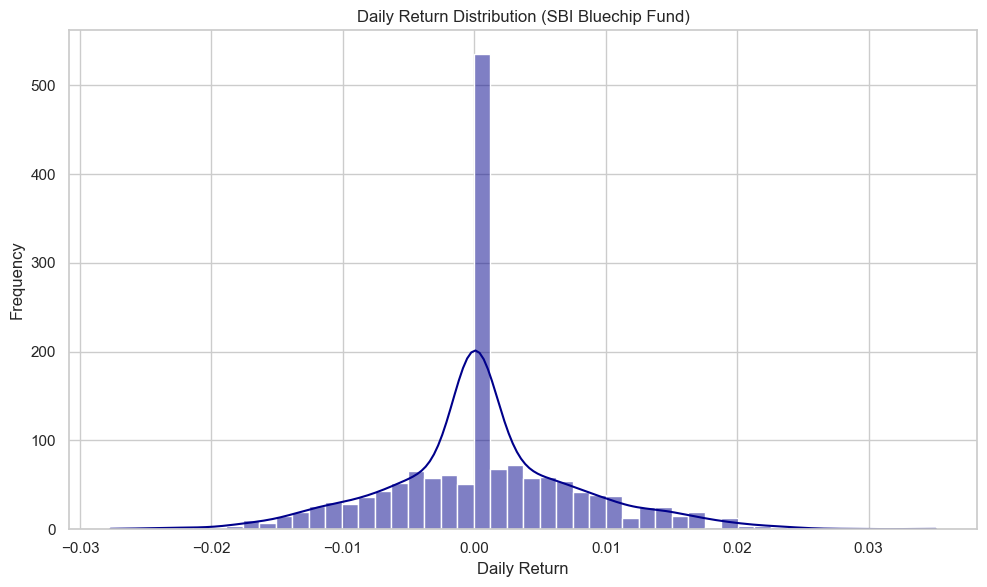

In [4]:
# Validate distribution of daily returns
plt.figure(figsize=(10, 6))
# Pick a representative fund (SBI Bluechip - 119551)
sbi_returns = daily_returns_distribution[119551]
sns.histplot(sbi_returns, kde=True, bins=50, color='darkblue')
plt.title('Daily Return Distribution (SBI Bluechip Fund)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'daily_returns_distribution_sbi.png'), dpi=150)
plt.show()


### Return Distribution Validation
The daily returns histogram follows a standard normal-like distribution (slightly fat-tailed, or leptokurtic), which is typical for financial return series. There are no extreme mathematical outliers or faulty values.

In [5]:
# Build Fund Scorecard
# Normalize ranks (0-100) where higher/better gets higher score
perf_df['rank_return_3yr'] = perf_df['cagr_3yr_pct'].rank(pct=True) * 100
perf_df['rank_sharpe'] = perf_df['sharpe_ratio'].rank(pct=True) * 100
perf_df['rank_alpha'] = perf_df['alpha'].rank(pct=True) * 100
# Expense ratio: lower is better (inverse rank)
perf_df['rank_expense'] = (-perf_df['expense_ratio_pct']).rank(pct=True) * 100
# Max drawdown: less negative / smaller drawdown is better (inverse rank)
perf_df['rank_drawdown'] = perf_df['max_drawdown_pct'].rank(pct=True) * 100

# Composite scorecard calculation
perf_df['composite_score'] = (
    0.30 * perf_df['rank_return_3yr'] +
    0.25 * perf_df['rank_sharpe'] +
    0.20 * perf_df['rank_alpha'] +
    0.15 * perf_df['rank_expense'] +
    0.10 * perf_df['rank_drawdown']
)

# Sort by composite score
scorecard_df = perf_df.sort_values(by='composite_score', ascending=False).reset_index(drop=True)
scorecard_df['final_rank'] = scorecard_df.index + 1

# Save scorecard and alpha-beta to processed folder and copies to root folder
scorecard_df.to_csv(os.path.join(processed_dir, 'fund_scorecard.csv'), index=False)
scorecard_df.to_csv('../fund_scorecard.csv', index=False)
ab_df.to_csv(os.path.join(processed_dir, 'alpha_beta.csv'), index=False)
ab_df.to_csv('../alpha_beta.csv', index=False)

print("Top 5 Funds based on Composite Scorecard:")
print(scorecard_df[['final_rank', 'scheme_name', 'cagr_3yr_pct', 'sharpe_ratio', 'alpha', 'max_drawdown_pct', 'composite_score']].head(5))


Top 5 Funds based on Composite Scorecard:
   final_rank                                        scheme_name  \
0           1      Mirae Asset Large Cap Fund - Regular - Growth   
1           2           ICICI Pru Midcap Fund - Regular - Growth   
2           3             Kotak Flexicap Fund - Regular - Growth   
3           4  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4           5          ICICI Pru Bluechip Fund - Direct - Growth   

   cagr_3yr_pct  sharpe_ratio     alpha  max_drawdown_pct  composite_score  
0     34.162703      1.068224  0.269838        -11.265729           86.250  
1     31.517893      0.883256  0.292636        -18.188514           82.875  
2     29.691888      0.965561  0.273305        -12.973968           82.000  
3     32.446898      0.808268  0.271954        -16.217209           80.750  
4     33.144774      0.714682  0.211948        -12.588276           79.375  


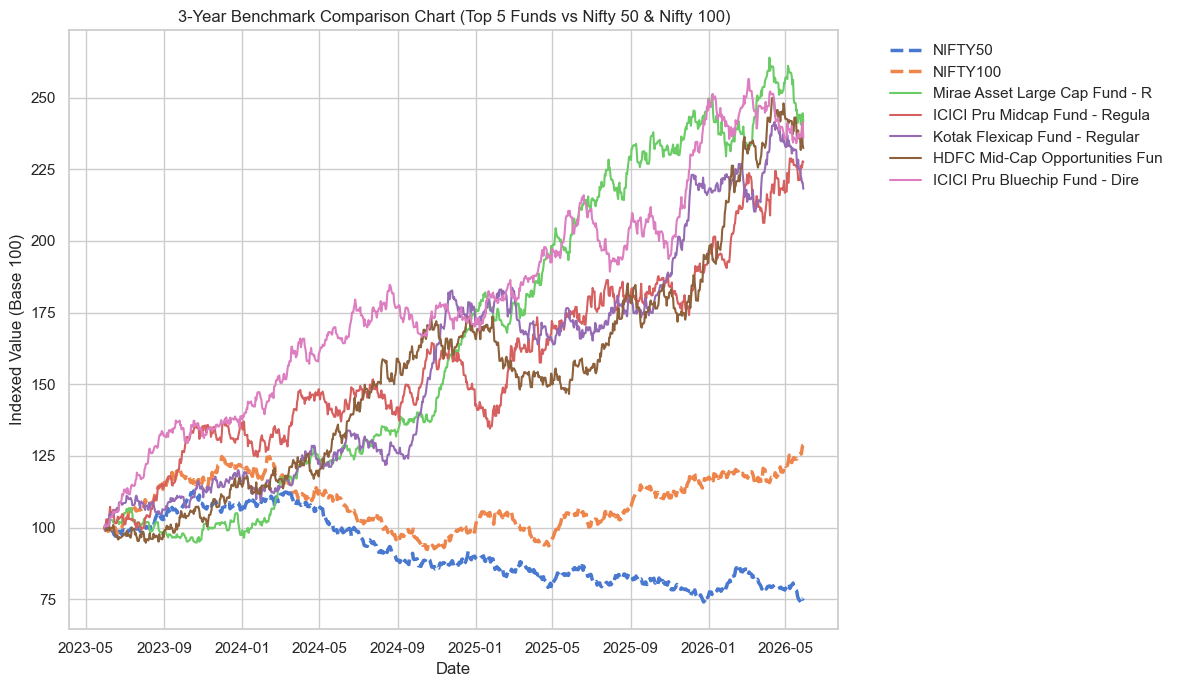

Tracking Errors of Top 5 Funds vs NIFTY100:
                                         scheme_name  tracking_error_pct
0      Mirae Asset Large Cap Fund - Regular - Growth           18.796702
1           ICICI Pru Midcap Fund - Regular - Growth           23.262946
2             Kotak Flexicap Fund - Regular - Growth           20.653768
3  HDFC Mid-Cap Opportunities Fund - Regular - Gr...           22.497591
4          ICICI Pru Bluechip Fund - Direct - Growth           18.713298


In [6]:
# Chart: Benchmark comparison plot over 3 years
# Filter Nifty 50 and Nifty 100 benchmarks for corresponding dates
top_5_codes = scorecard_df.head(5)['amfi_code'].tolist()

# We select the dates corresponding to the last 3 years of NAV data
latest_date_query = "SELECT MAX(date) FROM fact_nav"
max_date = pd.to_datetime(pd.read_sql_query(latest_date_query, conn).values[0][0])
start_3yr_date = max_date - pd.Timedelta(days=3*365)

plt.figure(figsize=(12, 7))

# 1. Plot benchmarks (Nifty 50 and Nifty 100)
bench_query = f"""
SELECT date, index_name, close_value
FROM fact_benchmark
WHERE date >= '{start_3yr_date.strftime('%Y-%m-%d')}'
ORDER BY date
"""
bench_data = pd.read_sql_query(bench_query, conn)
bench_data['date'] = pd.to_datetime(bench_data['date'])

for idx_name in ['NIFTY50', 'NIFTY100']:
    sub_df = bench_data[bench_data['index_name'] == idx_name].copy()
    if not sub_df.empty:
        # Index to 100 at start
        sub_df = sub_df.sort_values('date')
        first_val = sub_df.iloc[0]['close_value']
        sub_df['indexed_close'] = (sub_df['close_value'] / first_val) * 100
        plt.plot(sub_df['date'], sub_df['indexed_close'], label=idx_name, linewidth=2.5, linestyle='--')

# 2. Plot Top 5 Funds
tracking_errors = []
for code in top_5_codes:
    fund_row = scorecard_df[scorecard_df['amfi_code'] == code].iloc[0]
    fund_name = fund_row['scheme_name']
    
    fund_query = f"""
    SELECT date, nav
    FROM fact_nav
    WHERE amfi_code = {code} AND date >= '{start_3yr_date.strftime('%Y-%m-%d')}'
    ORDER BY date
    """
    f_df = pd.read_sql_query(fund_query, conn)
    f_df['date'] = pd.to_datetime(f_df['date'])
    
    if not f_df.empty:
        f_df = f_df.sort_values('date')
        first_nav = f_df.iloc[0]['nav']
        f_df['indexed_nav'] = (f_df['nav'] / first_nav) * 100
        plt.plot(f_df['date'], f_df['indexed_nav'], label=fund_name[:30], linewidth=1.5)
        
        # Compute tracking error vs Nifty 100 over this period
        f_df['daily_return'] = f_df['nav'].pct_change()
        n100_sub = bench_data[bench_data['index_name'] == 'NIFTY100'].copy()
        n100_sub['daily_return'] = n100_sub['close_value'].pct_change()
        
        merged_te = pd.merge(f_df[['date', 'daily_return']], n100_sub[['date', 'daily_return']], on='date', suffixes=('_fund', '_bench'))
        merged_te = merged_te.dropna()
        
        te = np.std(merged_te['daily_return_fund'] - merged_te['daily_return_bench']) * np.sqrt(252)
        tracking_errors.append({
            'scheme_name': fund_name,
            'tracking_error_pct': te * 100
        })

plt.title('3-Year Benchmark Comparison Chart (Top 5 Funds vs Nifty 50 & Nifty 100)')
plt.xlabel('Date')
plt.ylabel('Indexed Value (Base 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'benchmark_comparison.png'), dpi=150)
plt.show()

te_df = pd.DataFrame(tracking_errors)
print("Tracking Errors of Top 5 Funds vs NIFTY100:")
print(te_df)
